# 📊 Capstone Project — Analisis Pasar Kerja IT di Indonesia (2026)

**Tim :** Dicoding Camp — Data Science  
**Sumber Data :** JobStreet & LinkedIn (April–Mei 2026)  
**Tujuan :** Menganalisis tren kebutuhan tenaga kerja IT di Indonesia berdasarkan data lowongan kerja yang dikumpulkan melalui web scraping.

---

## 🎯 Pertanyaan SMART (Specific, Measurable, Achievable, Relevant, Time-bound)

| # | Pertanyaan | Relevansi |
|---|-----------|----------|
| Q1 | Role IT apa yang paling banyak dibutuhkan di Indonesia pada April–Mei 2026? | Membantu job seeker memilih karir yang paling banyak diminati perusahaan |
| Q2 | Skill teknis apa yang paling sering diminta per role? | Memandu perencanaan belajar/upskilling yang tepat sasaran |
| Q3 | Berapa rata-rata salary per role dan bagaimana distribusinya? | Memberikan acuan negosiasi gaji yang realistis |
| Q4 | Bagaimana distribusi job level (Junior/Mid/Senior) antar role? | Mengetahui tingkat persaingan per jenjang karir |
| Q5 | Apakah ada korelasi antara jumlah skill yang diminta dengan besaran salary? | Mengukur apakah menguasai lebih banyak skill berdampak pada gaji |

---


## 1. Import Library

In [2]:
import ast
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
print('✅ Library berhasil diimpor')

✅ Library berhasil diimpor


## 2. Load Dataset

Dataset diperoleh dari dua sumber:
- **JobStreet** : Data lowongan kerja IT di Indonesia hasil web scraping menggunakan Selenium
- **LinkedIn** : Data lowongan kerja IT di Indonesia hasil web scraping

Kedua dataset akan digabungkan dan diselaraskan kolomnya sebelum dianalisis.

In [32]:
# Load dataset JobStreet
df = pd.read_csv('jobstreet_clean_20260602_185930.csv')

# Pilih kolom yang relevan
selected_columns = [
    'id', 'title', 'search_role', 'job_level', 'company',
    'location', 'salary_avg', 'extracted_skills',
    'skills_count', 'job_description', 'job_url', 'scraped_at'
]
df = df[[col for col in selected_columns if col in df.columns]]

print(f'JobStreet shape : {df.shape}')
df.head(30)

JobStreet shape : (6973, 12)


,id,title,search_role,job_level,company,location,salary_avg,extracted_skills,skills_count,job_description,job_url,scraped_at
0,91845414,AI Officer (Part-Time/Project-Based),ML Engineer,Junior,PT Intinusa Teknik Sejahtera,Tidak Disebutkan,NaN,"['python', 'r', 'pytorch', 'scikit-learn', 'te...",5,PT. Intinusa Teknik Sejahtera saat ini sedang ...,https://id.jobstreet.com/id/job/91845414,2026-05-02 00:35:45.912218
1,91843075,Engineering Staff,ML Engineer,Junior,PT SHARP Electronics Indonesia,Tidak Disebutkan,7000000.0,['r'],1,"Job Description\n\nNew Product Development, ex...",https://id.jobstreet.com/id/job/91843075,2026-05-02 00:35:54.296222
2,91847712,Programmable Logic Controller (PLC) Automation...,ML Engineer,Senior,(IDN) PT Ecolab International Indonesia,Tidak Disebutkan,NaN,['r'],1,Core Job Responsibilities\n\nPLC/SCADA Program...,https://id.jobstreet.com/id/job/91847712,2026-05-02 00:36:11.155039
3,91826101,Automation Technician,ML Engineer,Tidak Disebutkan,PT DISTRIBUTOR KOMPONEN UTAMA,Tidak Disebutkan,6750000.0,['r'],1,Pria/wanita\n\nGelar Sarjana Teknik (S1) Jurus...,https://id.jobstreet.com/id/job/91826101,2026-05-02 00:36:23.764667
4,91814983,Application Engineer – Process Analyzer & Inst...,ML Engineer,Senior,PT Indojaya Mitra Sarana,Tidak Disebutkan,NaN,['r'],1,PT Indojaya Mitra Sarana is an established aut...,https://id.jobstreet.com/id/job/91814983,2026-05-02 00:36:36.344591
5,91812296,Packing Line Technology & Engineering,ML Engineer,Senior,ParagonCorp,Tidak Disebutkan,NaN,"['git', 'scala', 'r']",3,"Deskripsi Pekerjaan Job Description\nDevelop, ...",https://id.jobstreet.com/id/job/91812296,2026-05-02 00:36:44.736806
6,91805749,EOS (Engineer On Site) – AIRPORT SEAMLESS SYST...,ML Engineer,Senior,PT CORRA SISTEM INTERGRASI,Tidak Disebutkan,NaN,"['scala', 'r']",2,WE’RE HIRING!\n\nEOS (Engineer On Site) – AIRP...,https://id.jobstreet.com/id/job/91805749,2026-05-02 00:36:53.264083
7,91805644,EOS (Engineer On Site) – AIRPORT SEAMLESS SYST...,ML Engineer,Senior,PT CORRA SISTEM INTERGRASI,Tidak Disebutkan,NaN,"['scala', 'r']",2,WE’RE HIRING!\n\nEOS (Engineer On Site) – AIRP...,https://id.jobstreet.com/id/job/91805644,2026-05-02 00:36:57.460421
8,91805538,EOS (Engineer On Site) – AIRPORT SEAMLESS SYST...,ML Engineer,Senior,PT CORRA SISTEM INTERGRASI,Tidak Disebutkan,NaN,"['scala', 'r']",2,WE’RE HIRING!\n\nEOS (Engineer On Site) – AIRP...,https://id.jobstreet.com/id/job/91805538,2026-05-02 00:37:01.680322
9,91805104,Site Engineer (MEP),ML Engineer,Tidak Disebutkan,PT Alam Sutera Realty Tbk,Tidak Disebutkan,NaN,['r'],1,Job Description:\n\nSupervise Electrical and M...,https://id.jobstreet.com/id/job/91805104,2026-05-02 00:37:05.947727


In [33]:
# Load dataset LinkedIn
df2 = pd.read_csv('linkedin_EDA.csv')
print(f'LinkedIn shape  : {df2.shape}')
df2.head()

LinkedIn shape  : (2334, 15)


,id,title,standardized_role,company,location,city,work_type,seniority,jd_length,job_description,extracted_skills,skills_count,job_url,search_role,scraped_at
0,4.354913e+09,Data Analyst,Data Analyst,ParagonCorp,"Jakarta, Indonesia (On-site)",Jakarta,On-site,Mid-level,1570,About the job\n\nJob Description\n\nDeliver in...,"['postgresql', 'power bi', 'python', 'sql', 't...",5,https://www.linkedin.com/jobs/view/4354913165/...,Data Scientist,2026-04-16T21:04:46.182549
1,4.401866e+09,Data Scientist,Data Scientist,Artajasa Pembayaran Elektronis,"Kota Tangerang Selatan, Banten, Indonesia (On-...",Kota Tangerang Selatan,On-site,Mid-level,2138,About the job\n\nPT Artajasa Pembayaran Elektr...,"['numpy', 'pandas', 'python', 'scikit-learn', ...",5,https://www.linkedin.com/jobs/view/4401866027/...,Data Scientist,2026-04-16T21:04:55.554607
2,4.402503e+09,Data Scientist (Remote),Data Scientist,Jobs Ai,APAC (Remote),APAC (Remote),Remote,Mid-level,2305,About the job\n\nRole: Data Scientist (Remote)...,"['python', 'sql']",2,https://www.linkedin.com/jobs/view/4402503224/...,Data Scientist,2026-04-16T21:05:00.274453
3,4.400761e+09,Data Scientist - AI/ML | Remote,Data Scientist,Crossing Hurdles,Indonesia (Remote),Indonesia (Remote),Remote,Mid-level,1411,About the job\n\nPosition: Data Scientist\n\nT...,['python'],1,https://www.linkedin.com/jobs/view/4400761315/...,Data Scientist,2026-04-16T21:05:19.200665
4,4.400158e+09,Data Analyst,Data Analyst,PT Siaga Abdi Utama,"Central Jakarta, Jakarta, Indonesia (On-site)",Central Jakarta,On-site,Mid-level,1127,About the job\n\nResponsibilities\n\nA Data An...,"['looker', 'solid', 'tableau']",3,https://www.linkedin.com/jobs/view/4400157751/...,Data Scientist,2026-04-16T21:05:23.910821


## 3. Data Wrangling

### 3.1 Standarisasi Kolom LinkedIn

Kolom LinkedIn memiliki nama yang berbeda dari JobStreet. Sebelum digabungkan, kolom-kolom perlu disesuaikan:
- `seniority` → `job_level`
- `standardized_role` → `search_role`  
- `city` → `location`

Kolom yang tidak relevan untuk analisis dihapus.

In [34]:
# Hapus kolom yang tidak diperlukan
df2 = df2.drop(columns=['search_role', 'location', 'work_type', 'jd_length'], errors='ignore')

# Sesuaikan nama kolom
df2 = df2.rename(columns={
    'seniority'         : 'job_level',
    'standardized_role' : 'search_role',
    'city'              : 'location'
})

print('Kolom LinkedIn setelah disesuaikan:')
print(df2.columns.tolist())
df2.head()

Kolom LinkedIn setelah disesuaikan:
['id', 'title', 'search_role', 'company', 'location', 'job_level', 'job_description', 'extracted_skills', 'skills_count', 'job_url', 'scraped_at']


,id,title,search_role,company,location,job_level,job_description,extracted_skills,skills_count,job_url,scraped_at
0,4.354913e+09,Data Analyst,Data Analyst,ParagonCorp,Jakarta,Mid-level,About the job\n\nJob Description\n\nDeliver in...,"['postgresql', 'power bi', 'python', 'sql', 't...",5,https://www.linkedin.com/jobs/view/4354913165/...,2026-04-16T21:04:46.182549
1,4.401866e+09,Data Scientist,Data Scientist,Artajasa Pembayaran Elektronis,Kota Tangerang Selatan,Mid-level,About the job\n\nPT Artajasa Pembayaran Elektr...,"['numpy', 'pandas', 'python', 'scikit-learn', ...",5,https://www.linkedin.com/jobs/view/4401866027/...,2026-04-16T21:04:55.554607
2,4.402503e+09,Data Scientist (Remote),Data Scientist,Jobs Ai,APAC (Remote),Mid-level,About the job\n\nRole: Data Scientist (Remote)...,"['python', 'sql']",2,https://www.linkedin.com/jobs/view/4402503224/...,2026-04-16T21:05:00.274453
3,4.400761e+09,Data Scientist - AI/ML | Remote,Data Scientist,Crossing Hurdles,Indonesia (Remote),Mid-level,About the job\n\nPosition: Data Scientist\n\nT...,['python'],1,https://www.linkedin.com/jobs/view/4400761315/...,2026-04-16T21:05:19.200665
4,4.400158e+09,Data Analyst,Data Analyst,PT Siaga Abdi Utama,Central Jakarta,Mid-level,About the job\n\nResponsibilities\n\nA Data An...,"['looker', 'solid', 'tableau']",3,https://www.linkedin.com/jobs/view/4400157751/...,2026-04-16T21:05:23.910821


### 3.2 Standarisasi Job Level

Kedua dataset menggunakan label job level yang berbeda-beda. Standarisasi dilakukan agar konsisten:
- `Intern` → `Junior`
- `Mid`, `Mid-level` → `Mid-level`
- `Managerial`, `Manager/Lead` → `Manager/Head`

In [35]:
level_mapping = {
    r'Intern'               : 'Junior',
    r'Mid|Mid-level'        : 'Mid-level',
    r'Managerial|Manager/Lead': 'Manager/Head'
}

df['job_level']  = df['job_level'].replace(level_mapping, regex=True)
df2['job_level'] = df2['job_level'].replace(level_mapping)

print('Distribusi job_level JobStreet:')
print(df['job_level'].value_counts().to_string())
print('\nDistribusi job_level LinkedIn:')
print(df2['job_level'].value_counts().to_string())

Distribusi job_level JobStreet:
job_level
Senior              2562
Tidak Disebutkan    2412
Junior              1588
Manager/Head         367
Mid-level             44

Distribusi job_level LinkedIn:
job_level
Mid-level       1707
Senior           366
Junior           174
Manager/Lead      87


### 3.3 Penggabungan Dataset

Kedua dataset digabungkan secara vertikal (concat). Setelah digabung, dilakukan pengecekan nilai null dan duplikat.

In [36]:
df_merge = pd.concat([df, df2], ignore_index=True)

print(f'Shape setelah merge : {df_merge.shape}')
print(f'\nJumlah nilai null per kolom:')
print(df_merge.isna().sum().to_string())

Shape setelah merge : (9307, 12)

Jumlah nilai null per kolom:
id                     0
title                  0
search_role            0
job_level              0
company                0
location               0
salary_avg          7281
extracted_skills       0
skills_count           0
job_description        6
job_url                0
scraped_at             0


### 3.4 Handling Missing Values — Lokasi

Lokasi yang bernilai `Tidak Disebutkan` diisi dengan `DKI Jakarta` karena mayoritas perusahaan IT di Indonesia berpusat di Jakarta, sehingga ini merupakan asumsi yang paling masuk akal.

In [37]:
before = (df_merge['location'] == 'Tidak Disebutkan').sum()
df_merge['location'] = df_merge['location'].replace('Tidak Disebutkan', 'DKI Jakarta')
print(f'Lokasi "Tidak Disebutkan" diganti DKI Jakarta: {before:,} baris')

Lokasi "Tidak Disebutkan" diganti DKI Jakarta: 6,973 baris


### 3.5 Cleaning Kolom Salary

Kolom `salary_avg` mengandung outlier dan nilai yang tidak valid:
- **Nilai < 1 juta** : kemungkinan bukan salary bulanan (misalnya satuan berbeda)
- **Nilai > 100 juta** : kemungkinan data entry error atau outlier ekstrem

Nilai-nilai tersebut diubah menjadi `NaN` dan akan diestimasi pada tahap berikutnya.

In [38]:
df_merge['salary_avg'] = pd.to_numeric(df_merge['salary_avg'], errors='coerce')

print('=== Distribusi Salary SEBELUM Cleaning ===')
print(df_merge['salary_avg'].describe())
print(f"\nNilai > 100 juta : {(df_merge['salary_avg'] > 100_000_000).sum():,} baris")
print(f"Nilai < 1 juta   : {((df_merge['salary_avg'] > 0) & (df_merge['salary_avg'] < 1_000_000)).sum():,} baris")
print(f"NaN              : {df_merge['salary_avg'].isna().sum():,} baris")

=== Distribusi Salary SEBELUM Cleaning ===
count    2.026000e+03
mean     9.424752e+06
std      7.697500e+06
min      4.505000e+05
25%      5.500000e+06
50%      7.500000e+06
75%      1.050000e+07
max      1.500000e+08
Name: salary_avg, dtype: float64

Nilai > 100 juta : 1 baris
Nilai < 1 juta   : 4 baris
NaN              : 7,281 baris


In [39]:
# Hapus nilai outlier
df_merge.loc[df_merge['salary_avg'] < 1_000_000,   'salary_avg'] = np.nan
df_merge.loc[df_merge['salary_avg'] > 100_000_000, 'salary_avg'] = np.nan

print('=== Distribusi Salary SESUDAH Cleaning ===')
print(df_merge['salary_avg'].describe())
print(f"\nNaN (akan diestimasi) : {df_merge['salary_avg'].isna().sum():,} baris")
print(f"Valid                 : {df_merge['salary_avg'].notna().sum():,} baris")

=== Distribusi Salary SESUDAH Cleaning ===
count    2.021000e+03
mean     9.372536e+06
std      7.032813e+06
min      1.000000e+06
25%      5.500000e+06
50%      7.500000e+06
75%      1.050000e+07
max      9.250000e+07
Name: salary_avg, dtype: float64

NaN (akan diestimasi) : 7,286 baris
Valid                 : 2,021 baris


### 3.6 Estimasi Salary — Hybrid Approach

Sebagian besar lowongan tidak mencantumkan salary. Untuk mengisi nilai yang hilang, digunakan pendekatan hybrid:

1. **Random Forest Regressor** — untuk role dengan ≥30 data aktual. Model dilatih menggunakan fitur `search_role`, `job_level`, `city`, dan `skills_count`.
2. **Median Bertingkat** — untuk role dengan <30 data aktual, menggunakan urutan:
   - Median (role + level + kota) → Median (role + level) → Median (role) → Median global

Pendekatan ini dipilih karena mempertahankan distribusi aktual sambil memberikan estimasi yang masuk akal untuk data yang tidak lengkap.

In [43]:
RANDOM_STATE   = 42
RF_MIN_SAMPLES = 30
feature_cols   = ['search_role', 'job_level', 'city', 'skills_count']

# Pastikan kolom city tersedia
if 'city' not in df_merge.columns:
    df_merge['city'] = df_merge['location'].str.split(',').str[0].str.strip()

# Inisialisasi kolom salary_source
df_merge['salary_source'] = np.where(df_merge['salary_avg'].notna(), 'actual', 'missing')

df_actual    = df_merge[df_merge['salary_avg'].notna()].copy()
missing_mask = df_merge['salary_avg'].isna()

print(f'Data aktual  : {len(df_actual):,} ({len(df_actual)/len(df_merge)*100:.1f}%)')
print(f'Data missing : {missing_mask.sum():,} ({missing_mask.sum()/len(df_merge)*100:.1f}%)')

Data aktual  : 9,307 (100.0%)
Data missing : 0 (0.0%)


In [44]:
# Tentukan role yang akan diestimasi dengan RF vs Median
role_counts = df_actual['search_role'].value_counts()
rf_roles    = role_counts[role_counts >= RF_MIN_SAMPLES].index.tolist()

rf_n  = df_merge[missing_mask & df_merge['search_role'].isin(rf_roles)].shape[0]
med_n = df_merge[missing_mask & ~df_merge['search_role'].isin(rf_roles)].shape[0]
print(f'RF  (≥{RF_MIN_SAMPLES} sampel) : {len(rf_roles)} role  → {rf_n:,} baris akan diestimasi')
print(f'Med (<{RF_MIN_SAMPLES} sampel) : {len(role_counts) - len(rf_roles)} role → {med_n:,} baris akan diestimasi')

# Lookup median bertingkat
global_med = df_actual['salary_avg'].median()
lkp3 = df_actual.groupby(['search_role','job_level','city'])['salary_avg'].median().to_dict()
lkp2 = df_actual.groupby(['search_role','job_level'])['salary_avg'].median().to_dict()
lkp1 = df_actual.groupby(['search_role'])['salary_avg'].median().to_dict()

def median_fallback(row):
    return (lkp3.get((row['search_role'], row['job_level'], row['city']))
         or lkp2.get((row['search_role'], row['job_level']))
         or lkp1.get(row['search_role'])
         or global_med)

RF  (≥30 sampel) : 9 role  → 0 baris akan diestimasi
Med (<30 sampel) : 0 role → 0 baris akan diestimasi


In [45]:
# ── Random Forest ──────────────────────────────────────────────────────────
rf_mask = missing_mask & df_merge['search_role'].isin(rf_roles)

if rf_mask.sum() > 0:
    df_enc = df_merge.copy()
    for col in ['search_role', 'job_level', 'city']:
        le = LabelEncoder()
        df_enc[col] = le.fit_transform(df_enc[col].astype(str).fillna('Unknown'))

    X_all    = df_enc[feature_cols].fillna(0)
    train_m  = df_merge['salary_avg'].notna() & df_merge['search_role'].isin(rf_roles)
    X_train  = X_all[train_m]
    y_train  = df_merge.loc[train_m, 'salary_avg']

    model_rf = RandomForestRegressor(
        n_estimators=300, max_depth=7,
        min_samples_leaf=10, random_state=RANDOM_STATE
    )
    model_rf.fit(X_train, y_train)

    cv_mae = -cross_val_score(model_rf, X_train, y_train,
                               scoring='neg_mean_absolute_error', cv=5).mean()
    cv_r2  =  cross_val_score(model_rf, X_train, y_train,
                               scoring='r2', cv=5).mean()
    print(f'🤖 RF dilatih dari {len(X_train):,} sampel')
    print(f'   CV MAE : Rp {cv_mae:,.0f}')
    print(f'   CV R²  : {cv_r2:.3f}')
    if cv_r2 < 0.3:
        print('   ⚠️  R² rendah — wajar dengan data terbatas')

    pred_rf = np.clip(model_rf.predict(X_all[rf_mask]), 1_000_000, 100_000_000)
    df_merge.loc[rf_mask, 'salary_avg']    = pred_rf
    df_merge.loc[rf_mask, 'salary_source'] = 'estimated_rf'

    # Feature importance
    fi = pd.Series(model_rf.feature_importances_, index=feature_cols).sort_values()
    fi.plot(kind='barh', title='Feature Importance — Salary RF',
            color='steelblue', figsize=(6, 3))
    plt.tight_layout()
    plt.show()

# ── Median fallback ────────────────────────────────────────────────────────
med_mask = missing_mask & ~df_merge['search_role'].isin(rf_roles)
if med_mask.sum() > 0:
    df_merge.loc[med_mask, 'salary_avg']    = df_merge[med_mask].apply(median_fallback, axis=1)
    df_merge.loc[med_mask, 'salary_source'] = 'estimated_median'

print('\n✅ Distribusi salary_source:')
print(df_merge['salary_source'].value_counts().to_string())


✅ Distribusi salary_source:
salary_source
actual    9307


Visualisasi berikut menunjukkan perbandingan distribusi salary antara data aktual dan hasil estimasi. Distribusi yang serupa menandakan estimasi tidak menyimpang jauh dari data nyata.

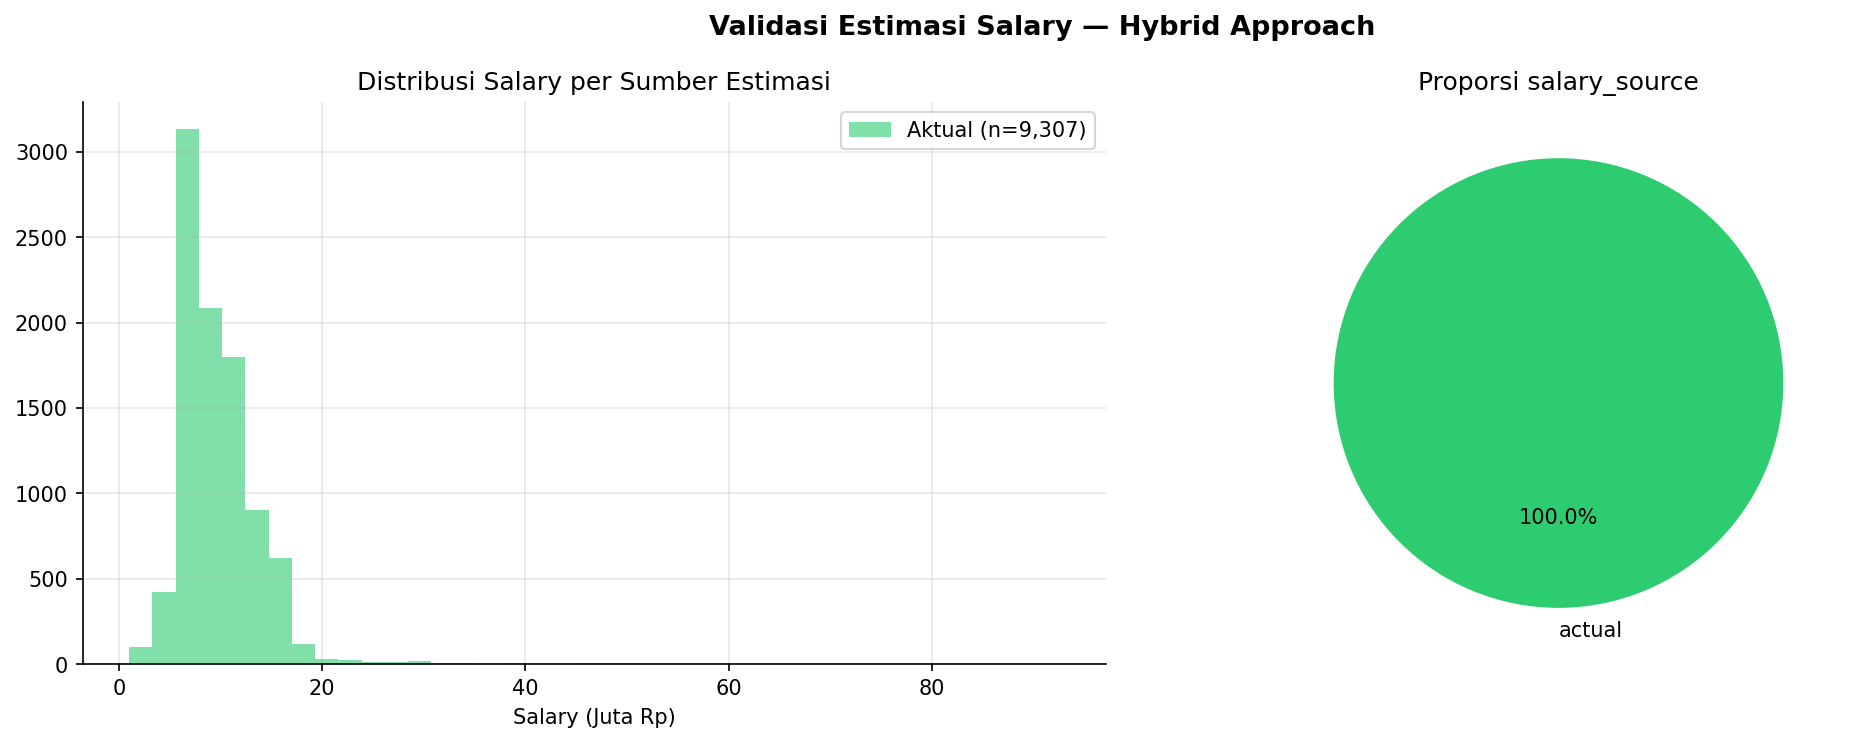

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for src, color, label in [
    ('actual',           '#2ecc71', 'Aktual'),
    ('estimated_rf',     '#3498db', 'Estimasi RF'),
    ('estimated_median', '#e67e22', 'Estimasi Median'),
]:
    vals = df_merge[df_merge['salary_source'] == src]['salary_avg'] / 1e6
    if len(vals) > 0:
        axes[0].hist(vals, bins=40, alpha=0.6,
                     label=f'{label} (n={len(vals):,})', color=color)

axes[0].set_xlabel('Salary (Juta Rp)')
axes[0].set_title('Distribusi Salary per Sumber Estimasi')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

src_counts = df_merge['salary_source'].value_counts()
axes[1].pie(src_counts.values, labels=src_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71', '#3498db', '#e67e22'],
            startangle=90)
axes[1].set_title('Proporsi salary_source')

plt.suptitle('Validasi Estimasi Salary — Hybrid Approach', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.7 Feature Engineering

Dua fitur baru ditambahkan untuk memperkaya analisis:

1. **`company_hiring_freq`** : Frekuensi kemunculan perusahaan dalam dataset, sebagai proxy aktivitas rekrutmen.
2. **`company_size_proxy`** : Kategorisasi perusahaan berdasarkan `company_hiring_freq` menjadi Small, Medium, Large, dan Enterprise.
3. **`title_seniority`** : Tingkat senioritas yang diekstrak dari judul pekerjaan menggunakan keyword matching.

> **Catatan** : Fitur-fitur ini **tidak dimasukkan sebagai fitur training model** karena mengandung informasi yang berpotensi menyebabkan data leakage (nilai dihitung dari keseluruhan dataset).

In [48]:
# company_hiring_freq & company_size_proxy
freq = df_merge['company'].value_counts()
df_merge['company_hiring_freq'] = df_merge['company'].map(freq)
df_merge['company_size_proxy']  = pd.cut(
    df_merge['company_hiring_freq'],
    bins=[0, 2, 5, 10, 9999],
    labels=['Small (1–2)', 'Medium (3–5)', 'Large (6–10)', 'Enterprise (10+)']
)

# title_seniority
SENIORITY_MAP = {
    'Head': 'Manager/Head', 'Director': 'Manager/Head', 'VP': 'Manager/Head',
    'Chief': 'Manager/Head', 'Lead': 'Manager/Head', 'Principal': 'Manager/Head',
    'Architect': 'Manager/Head', 'Manager': 'Manager/Head',
    'Senior': 'Senior', 'Sr.': 'Senior', 'Sr ': 'Senior',
    'Mid': 'Mid-level', 'Associate': 'Mid-level', 'Staff': 'Mid-level', 'Specialist': 'Mid-level',
    'Junior': 'Junior', 'Jr.': 'Junior', 'Jr ': 'Junior',
    'Entry': 'Junior', 'Intern': 'Junior', 'Magang': 'Junior', 'Fresh': 'Junior',
}

def extract_seniority(title):
    if not isinstance(title, str):
        return 'Tidak Disebutkan'
    for keyword, level in SENIORITY_MAP.items():
        if keyword.lower() in title.lower():
            return level
    return 'Tidak Disebutkan'

df_merge['title_seniority'] = df_merge['title'].apply(extract_seniority)

print('✅ Feature engineering selesai')
print(f'Kolom baru: company_hiring_freq, company_size_proxy, title_seniority')
print(f'\nDistribusi company_size_proxy:')
print(df_merge['company_size_proxy'].value_counts().to_string())

✅ Feature engineering selesai
Kolom baru: company_hiring_freq, company_size_proxy, title_seniority

Distribusi company_size_proxy:
company_size_proxy
Small (1–2)         3366
Enterprise (10+)    2574
Medium (3–5)        1881
Large (6–10)        1486


### 3.8 Dataset Akhir

Dataset hasil cleaning dan preprocessing disimpan sebagai `FinalFile_EDA.csv`. Kolom `salary_source` dan `city` dihapus karena hanya digunakan dalam proses estimasi, bukan untuk analisis lanjutan.

In [49]:
df_merge.drop(columns=['salary_source', 'city'], inplace=True, errors='ignore')
df_merge.to_csv('FinalFile_EDA.csv', index=False)

print(f'✅ Dataset final tersimpan: FinalFile_EDA.csv')
print(f'   Shape : {df_merge.shape}')
print(f'   Kolom : {df_merge.columns.tolist()}')
df_merge.head()

✅ Dataset final tersimpan: FinalFile_EDA.csv
   Shape : (9307, 15)
   Kolom : ['id', 'title', 'search_role', 'job_level', 'company', 'location', 'salary_avg', 'extracted_skills', 'skills_count', 'job_description', 'job_url', 'scraped_at', 'company_hiring_freq', 'company_size_proxy', 'title_seniority']


,id,title,search_role,job_level,company,location,salary_avg,extracted_skills,skills_count,job_description,job_url,scraped_at,company_hiring_freq,company_size_proxy,title_seniority
0,91845414.0,AI Officer (Part-Time/Project-Based),ML Engineer,Junior,PT Intinusa Teknik Sejahtera,DKI Jakarta,7.588172e+06,"['python', 'r', 'pytorch', 'scikit-learn', 'te...",5,PT. Intinusa Teknik Sejahtera saat ini sedang ...,https://id.jobstreet.com/id/job/91845414,2026-05-02 00:35:45.912218,3,Medium (3–5),Tidak Disebutkan
1,91843075.0,Engineering Staff,ML Engineer,Junior,PT SHARP Electronics Indonesia,DKI Jakarta,7.000000e+06,['r'],1,"Job Description\n\nNew Product Development, ex...",https://id.jobstreet.com/id/job/91843075,2026-05-02 00:35:54.296222,3,Medium (3–5),Mid-level
2,91847712.0,Programmable Logic Controller (PLC) Automation...,ML Engineer,Senior,(IDN) PT Ecolab International Indonesia,DKI Jakarta,1.116997e+07,['r'],1,Core Job Responsibilities\n\nPLC/SCADA Program...,https://id.jobstreet.com/id/job/91847712,2026-05-02 00:36:11.155039,1,Small (1–2),Tidak Disebutkan
3,91826101.0,Automation Technician,ML Engineer,Tidak Disebutkan,PT DISTRIBUTOR KOMPONEN UTAMA,DKI Jakarta,6.750000e+06,['r'],1,Pria/wanita\n\nGelar Sarjana Teknik (S1) Jurus...,https://id.jobstreet.com/id/job/91826101,2026-05-02 00:36:23.764667,3,Medium (3–5),Tidak Disebutkan
4,91814983.0,Application Engineer – Process Analyzer & Inst...,ML Engineer,Senior,PT Indojaya Mitra Sarana,DKI Jakarta,1.116997e+07,['r'],1,PT Indojaya Mitra Sarana is an established aut...,https://id.jobstreet.com/id/job/91814983,2026-05-02 00:36:36.344591,1,Small (1–2),Tidak Disebutkan


---
## 4. Exploratory Data Analysis (EDA)

EDA dilakukan untuk menjawab 5 pertanyaan SMART yang telah dirumuskan di awal.

### Konfigurasi Visualisasi

In [50]:
ROLE_COLORS = {
    'Backend Developer'  : '#03045E',
    'Frontend Developer' : '#023E8A',
    'Fullstack Developer': '#0077B6',
    'Data Analyst'       : '#0096C7',
    'Data Engineer'      : '#00B4D8',
    'Data Scientist'     : '#48CAE4',
    'ML Engineer'        : '#90E0EF',
    'DevOps Engineer'    : '#ADE8F4',
    'Software Engineer'  : '#CAF0F8'
}

plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'figure.dpi'        : 150,
})

# Parse extracted_skills
def parse_skills(val):
    if isinstance(val, list): return val
    if not val or str(val).strip() in ('', 'nan', '[]'): return []
    try: return ast.literal_eval(val)
    except: return []

df_merge['extracted_skills'] = df_merge['extracted_skills'].apply(parse_skills)
df_merge['scraped_at']       = pd.to_datetime(df_merge['scraped_at'], errors='coerce')

ROLE_ORDER = [
    'Backend Developer', 'Frontend Developer', 'Fullstack Developer',
    'Data Analyst', 'Data Engineer', 'Data Scientist',
    'ML Engineer', 'DevOps Engineer', 'Software Engineer'
]
ROLE_ORDER = [r for r in ROLE_ORDER if r in df_merge['search_role'].unique()]

print('✅ Konfigurasi siap, ROLE_ORDER:', ROLE_ORDER)

✅ Konfigurasi siap, ROLE_ORDER: ['Backend Developer', 'Frontend Developer', 'Fullstack Developer', 'Data Analyst', 'Data Engineer', 'Data Scientist', 'ML Engineer', 'DevOps Engineer', 'Software Engineer']


---
### Q1 — Role IT Paling Banyak Dibutuhkan

**Pertanyaan:** Role IT apa yang paling banyak dibutuhkan di Indonesia pada April–Mei 2026?

Visualisasi berikut menampilkan jumlah dan persentase lowongan kerja per role IT, diurutkan dari yang paling banyak ke paling sedikit.

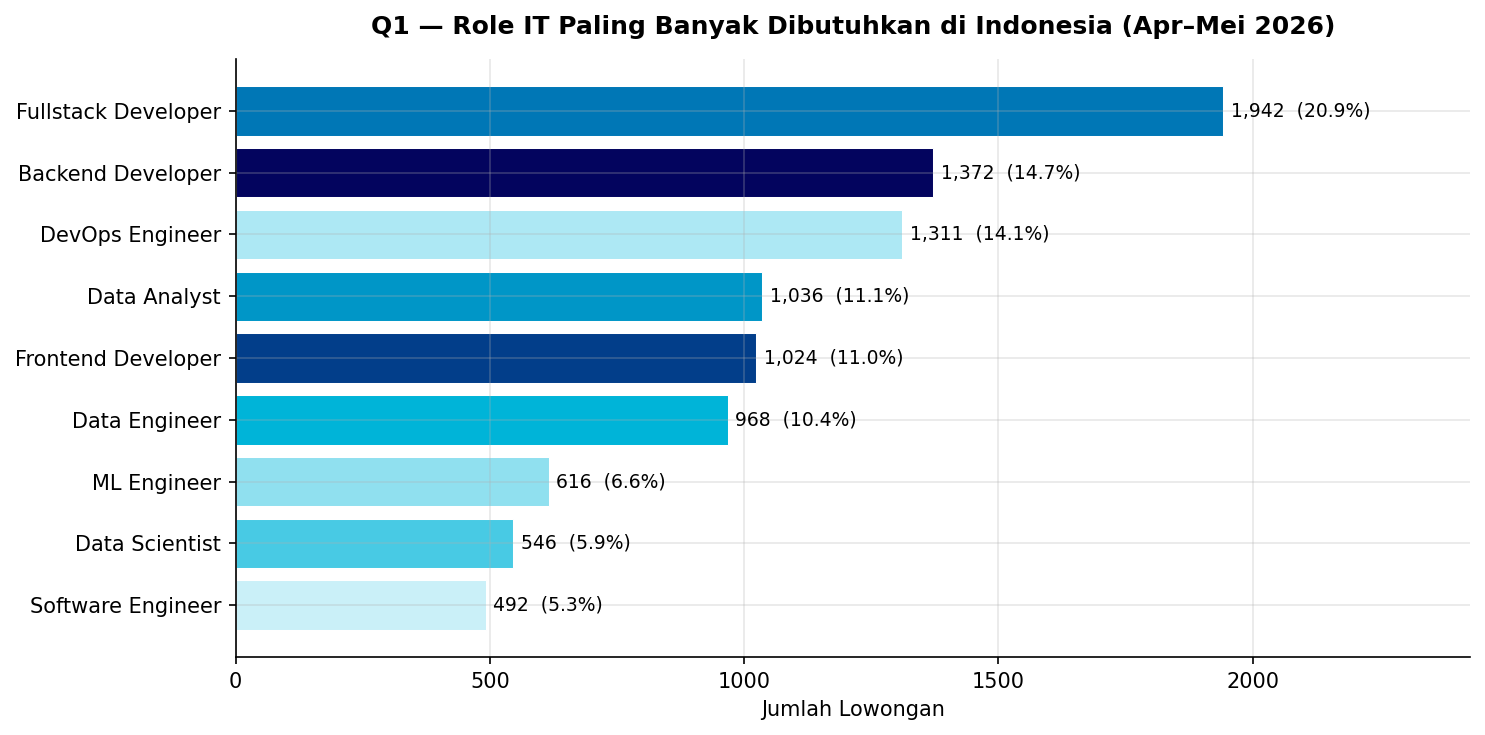

In [51]:
role_counts = df_merge['search_role'].value_counts()
pcts        = (role_counts / role_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(role_counts.index[::-1], role_counts.values[::-1],
               color=[ROLE_COLORS.get(r, '#999') for r in role_counts.index[::-1]],
               edgecolor='white', linewidth=0.5)

for bar, val, pct in zip(bars, role_counts.values[::-1], pcts.values[::-1]):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({pct}%)', va='center', fontsize=9)

ax.set_xlabel('Jumlah Lowongan')
ax.set_title('Q1 — Role IT Paling Banyak Dibutuhkan di Indonesia (Apr–Mei 2026)',
             fontweight='bold', pad=12)
ax.set_xlim(0, role_counts.max() * 1.25)
fig.tight_layout()
plt.show()

**Insight Q1:**
Berdasarkan visualisasi di atas, dapat disimpulkan bahwa:
- Role **Backend Developer** dan **Software Engineer** mendominasi pasar kerja IT Indonesia pada periode April–Mei 2026
- Role **Data Scientist** dan **DevOps Engineer** memiliki jumlah lowongan yang relatif lebih sedikit, menunjukkan permintaan yang lebih spesifik
- Secara keseluruhan, demand untuk developer (Frontend, Backend, Fullstack) lebih tinggi dibanding data roles

---
### Q2 — Skill Teknis Paling Sering Diminta per Role

**Pertanyaan:** Skill teknis apa yang paling sering diminta per role?

Analisis ini dilakukan dengan menghitung frekuensi kemunculan setiap skill di dalam `extracted_skills` per role. Top 8 skill ditampilkan untuk setiap role.

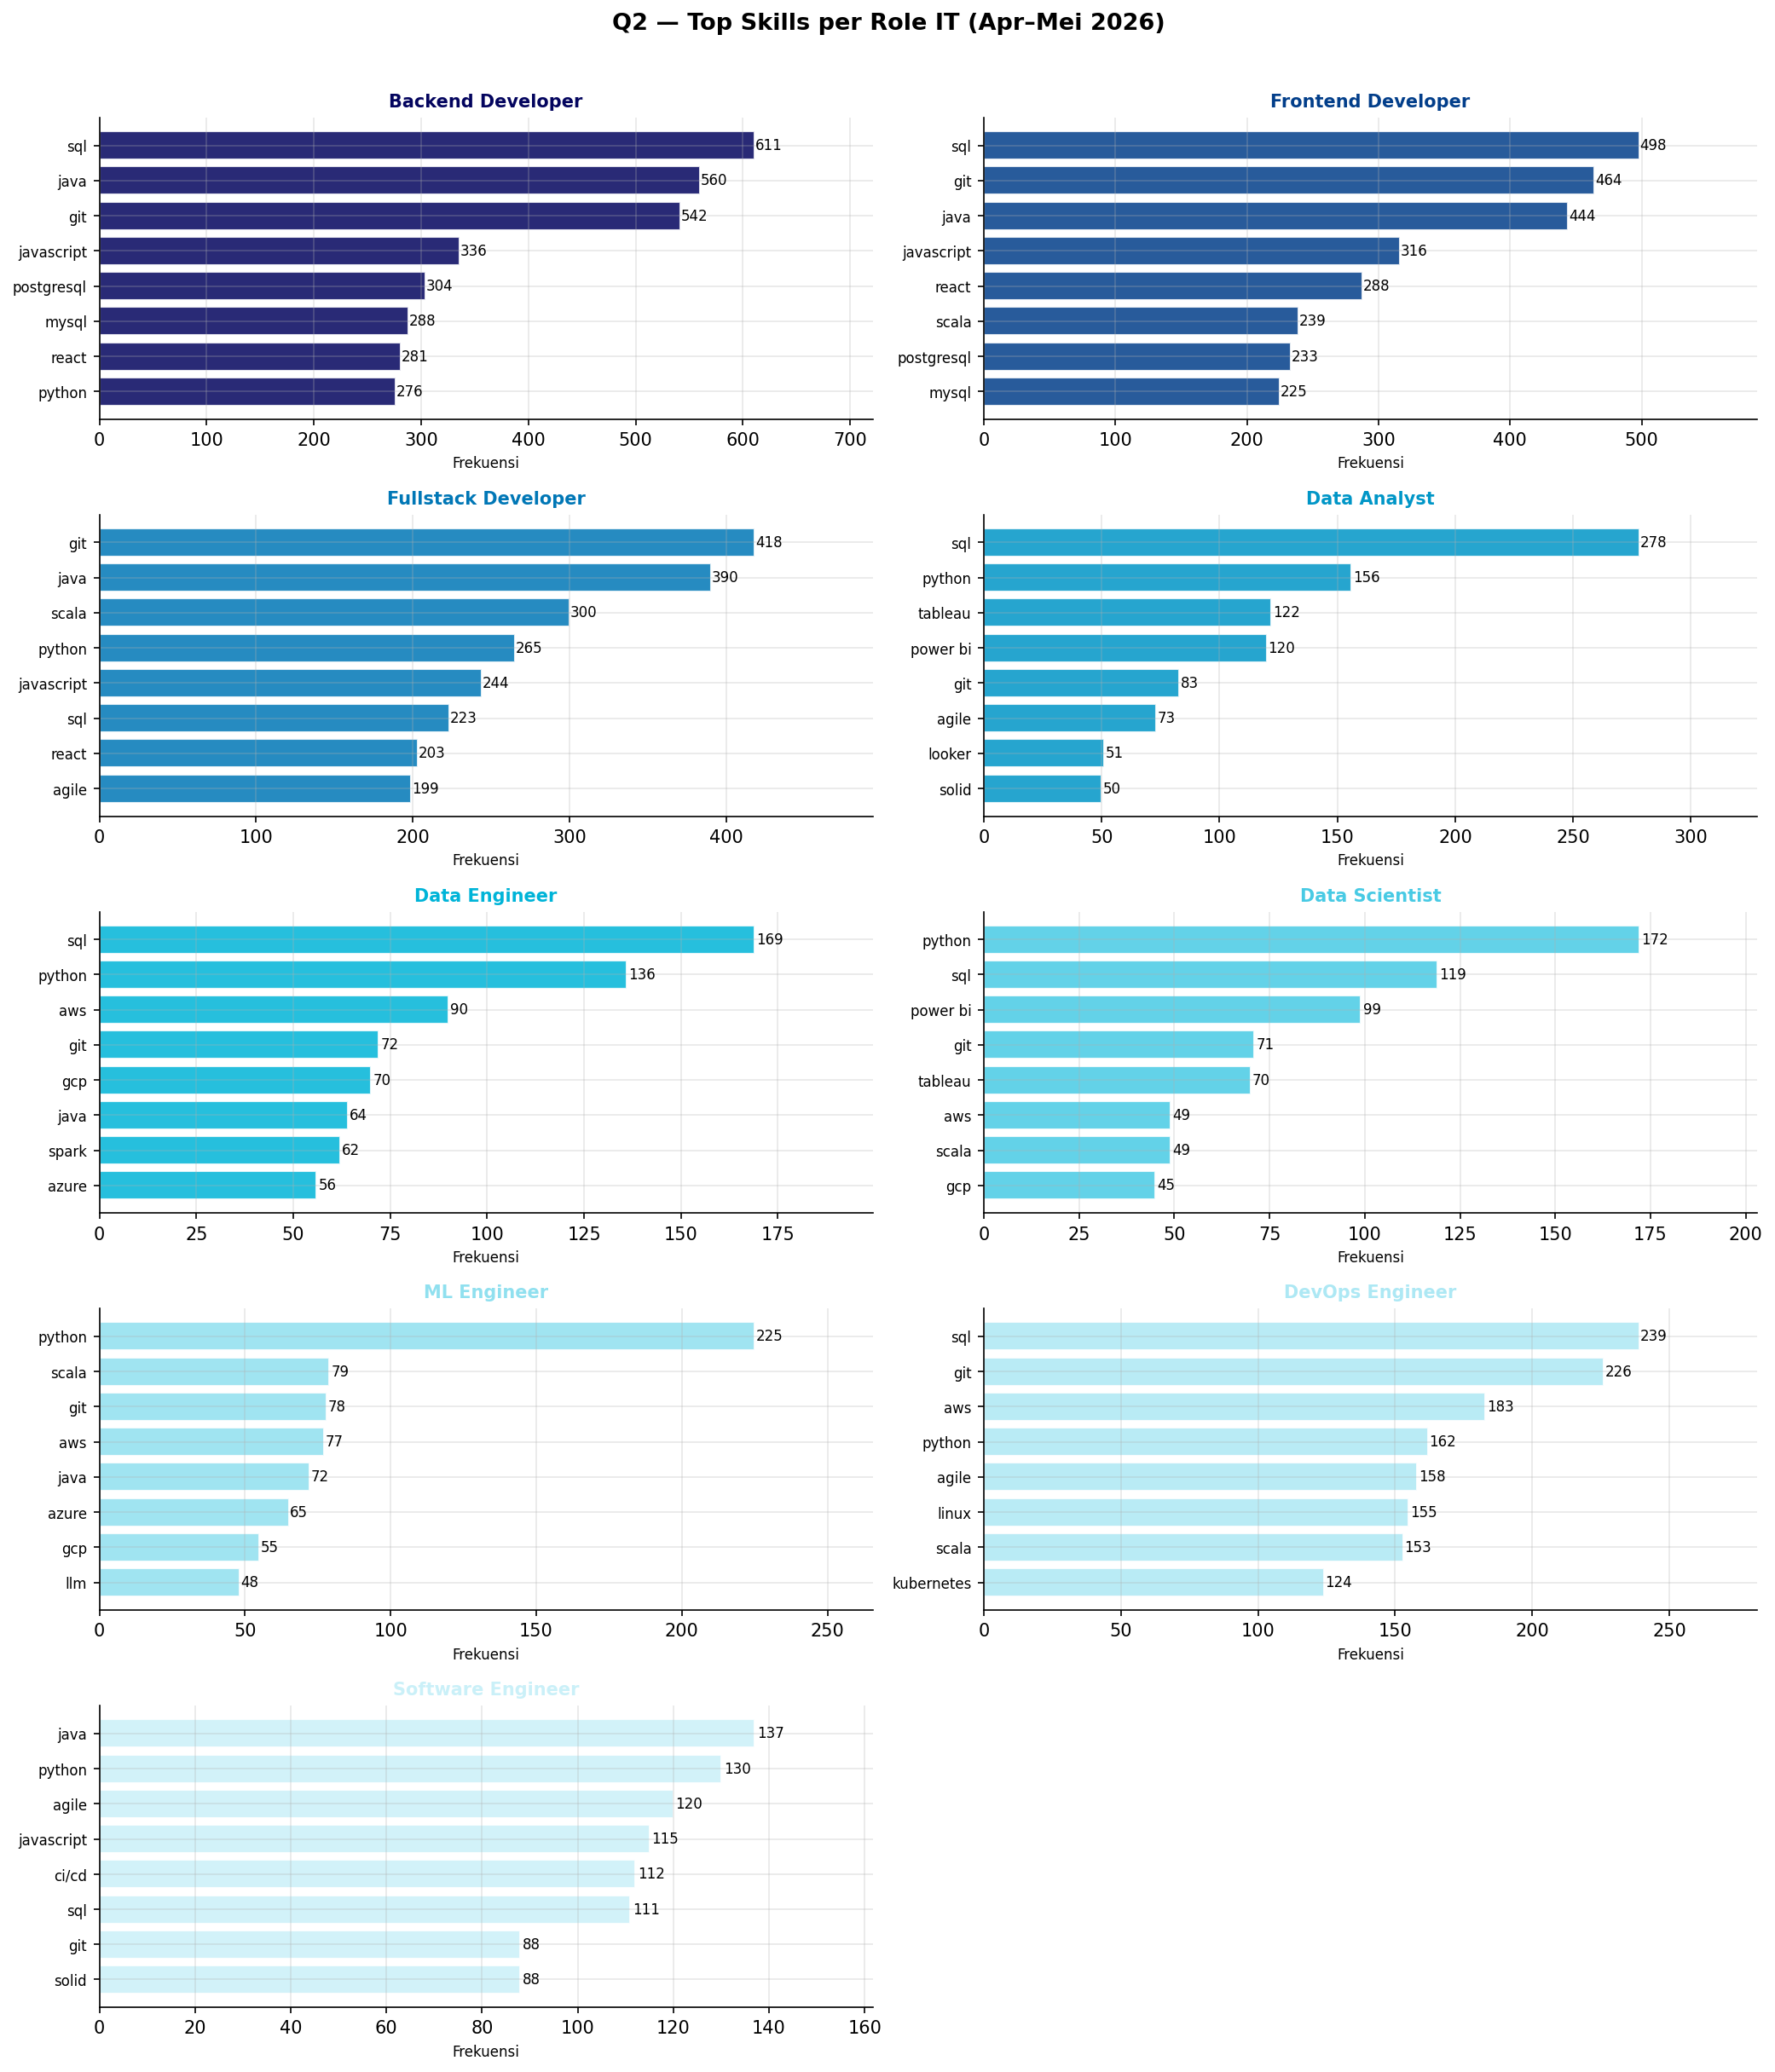

In [52]:
TOP_N  = 8
nrows  = (len(ROLE_ORDER) + 1) // 2

fig, axes = plt.subplots(nrows, 2, figsize=(14, nrows * 3.2))
axes      = axes.flatten()

for i, role in enumerate(ROLE_ORDER):
    ax      = axes[i]
    subset  = df_merge[df_merge['search_role'] == role]
    flat    = [s for row in subset['extracted_skills'] for s in row]
    counter = Counter(flat)
    counter.pop('r', None)  # hapus noise

    top = counter.most_common(TOP_N)
    if not top:
        ax.set_visible(False)
        continue

    skills, counts = zip(*top)
    color = ROLE_COLORS.get(role, '#999')

    ax.barh(list(skills)[::-1], list(counts)[::-1],
            color=color, alpha=0.85, edgecolor='white')
    for j, (sk, ct) in enumerate(zip(list(skills)[::-1], list(counts)[::-1])):
        ax.text(ct + 0.5, j, str(ct), va='center', fontsize=8)

    ax.set_title(role, fontweight='bold', color=color, fontsize=10)
    ax.set_xlabel('Frekuensi', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_xlim(0, list(counts)[0] * 1.18)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Q2 — Top Skills per Role IT (Apr–Mei 2026)',
             fontweight='bold', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

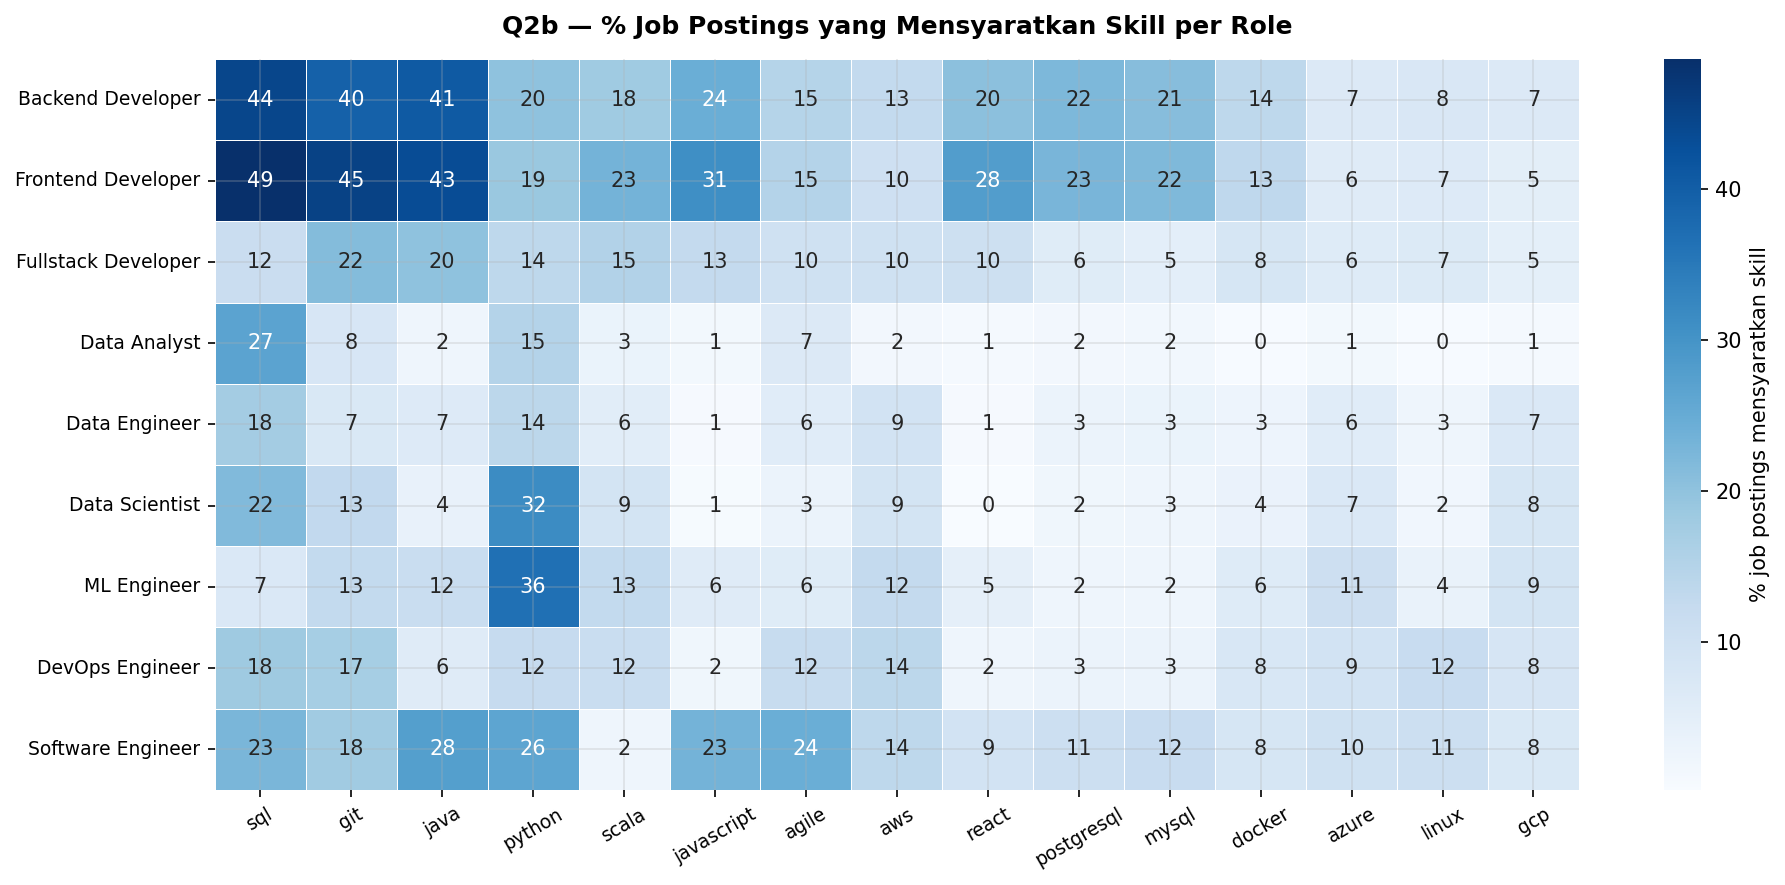

In [53]:
# Heatmap persentase skill per role
all_skills_flat = [s for row in df_merge['extracted_skills'] for s in row if s != 'r']
top_global      = [s for s, _ in Counter(all_skills_flat).most_common(15)]

heat_data = {}
for role in ROLE_ORDER:
    sub  = df_merge[df_merge['search_role'] == role]
    n    = len(sub)
    flat = [s for row in sub['extracted_skills'] for s in row]
    cnt  = Counter(flat)
    heat_data[role] = {sk: round(cnt.get(sk, 0) / n * 100, 1) for sk in top_global}

heat_df = pd.DataFrame(heat_data, index=top_global).T

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(heat_df, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': '% job postings mensyaratkan skill'}, ax=ax)
ax.set_title('Q2b — % Job Postings yang Mensyaratkan Skill per Role',
             fontweight='bold', pad=12)
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', labelsize=9)
fig.tight_layout()
plt.show()

**Insight Q2:**
- **SQL** dan **Python** menjadi skill paling universal — diminta hampir di semua role, terutama data roles
- **JavaScript/TypeScript** mendominasi Frontend dan Fullstack Developer
- **Docker** dan **AWS** menjadi kebutuhan utama DevOps Engineer
- **PyTorch** dan **TensorFlow** spesifik untuk ML Engineer dan Data Scientist
- Heatmap menunjukkan ada skill yang sangat spesifik per role (warna gelap hanya di satu baris)

---
### Q3 — Rata-rata Salary per Role

**Pertanyaan:** Berapa rata-rata salary per role dan bagaimana distribusinya?

Analisis salary menggunakan nilai `salary_avg` yang telah dibersihkan dan diestimasi pada tahap preprocessing.

/tmp/ipykernel_2146/3499134815.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(avg_sal.index, rotation=25, ha='right', fontsize=9)


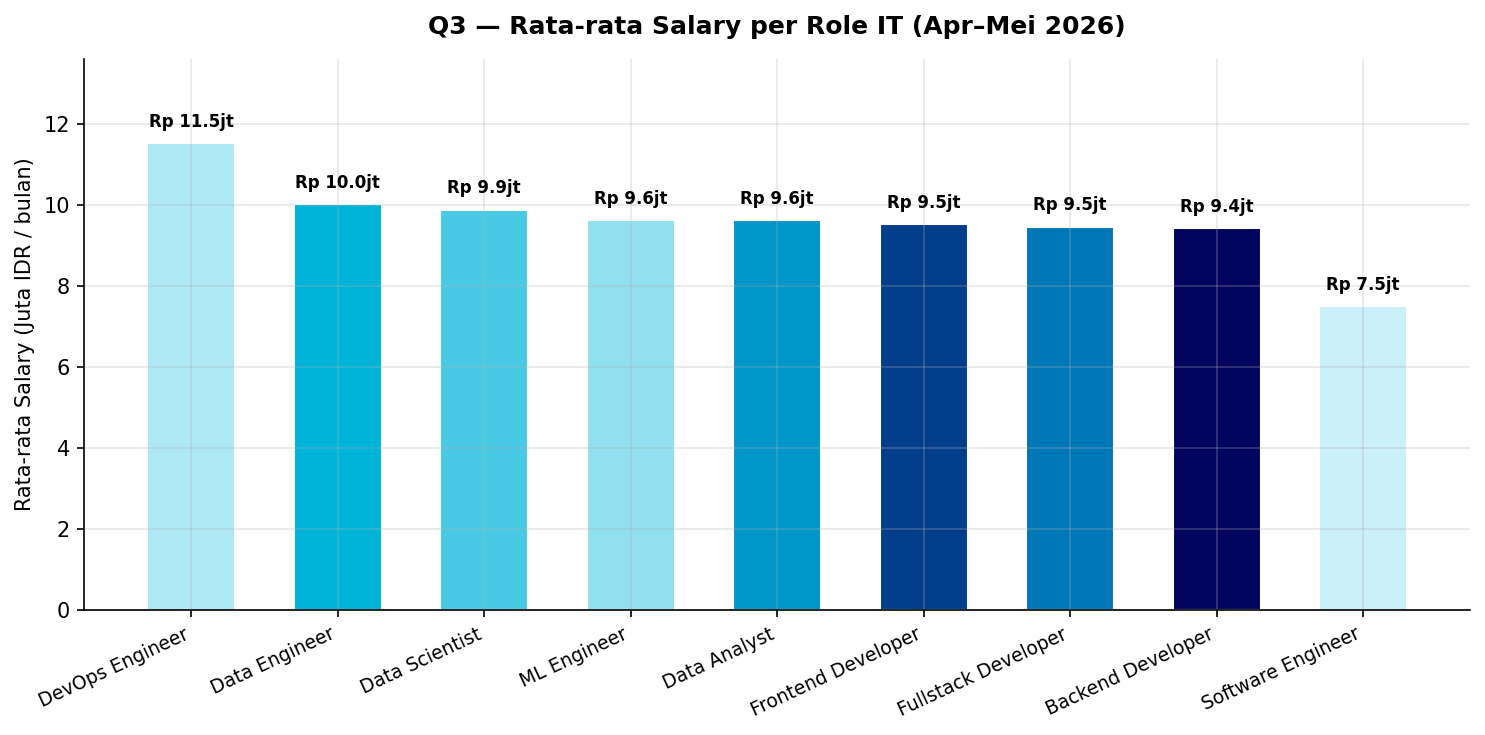

In [54]:
df_sal = df_merge[df_merge['salary_avg'].notna()].copy()
df_sal['salary_avg_jt'] = df_sal['salary_avg'] / 1_000_000

avg_sal = (df_sal.groupby('search_role')['salary_avg_jt']
           .mean().reindex(ROLE_ORDER).dropna()
           .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(avg_sal.index, avg_sal.values,
              color=[ROLE_COLORS.get(r, '#999') for r in avg_sal.index],
              edgecolor='white', width=0.6)

for bar, val in zip(bars, avg_sal.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'Rp {val:.1f}jt', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_ylabel('Rata-rata Salary (Juta IDR / bulan)')
ax.set_title('Q3 — Rata-rata Salary per Role IT (Apr–Mei 2026)',
             fontweight='bold', pad=12)
ax.set_xticklabels(avg_sal.index, rotation=25, ha='right', fontsize=9)
ax.set_ylim(0, avg_sal.max() * 1.18)
fig.tight_layout()
plt.show()

**Insight Q3:**
- Role yang berhubungan dengan data (**Data Scientist**, **ML Engineer**, **Data Engineer**) cenderung memiliki rata-rata salary lebih tinggi
- **Software Engineer** dan **DevOps Engineer** juga berada di tier atas
- **Frontend Developer** memiliki rata-rata salary terendah di antara semua role
- Selisih antara role tertinggi dan terendah mencerminkan tingkat spesialisasi yang dibutuhkan

---
### Q4 — Distribusi Job Level per Role

**Pertanyaan:** Bagaimana distribusi job level (Junior/Mid/Senior) antar role?

Visualisasi stacked bar menampilkan proporsi setiap level pekerjaan untuk masing-masing role.

/tmp/ipykernel_2146/3420958822.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ROLE_ORDER, rotation=25, ha='right', fontsize=9)


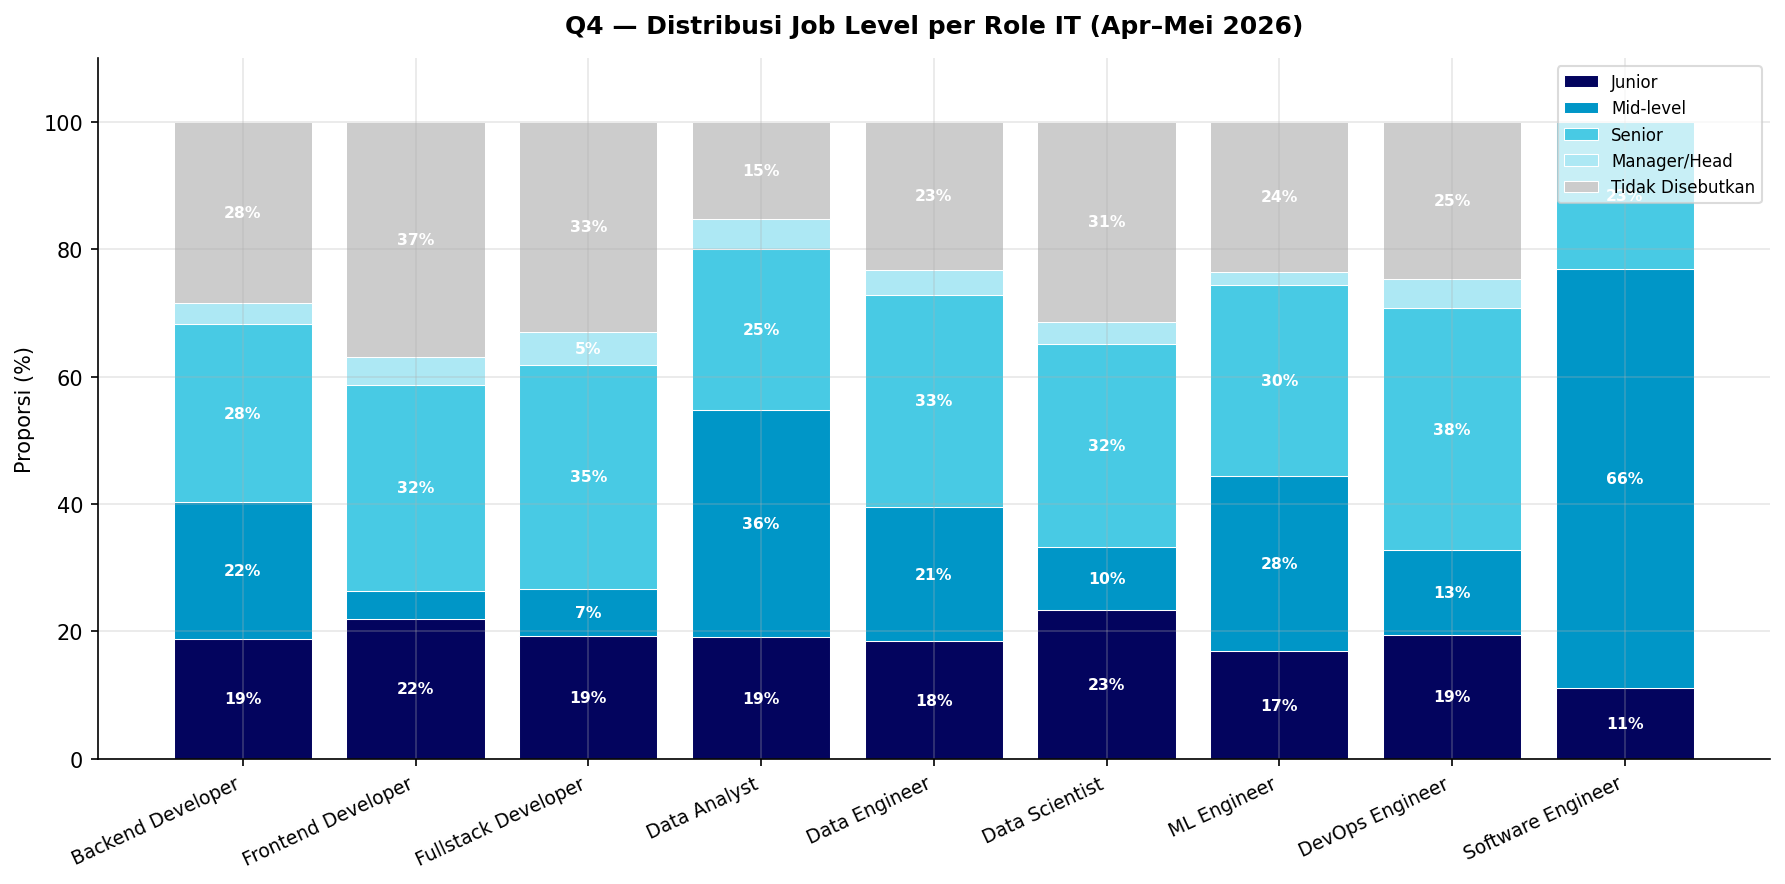

In [55]:
LEVEL_ORDER  = ['Junior', 'Mid-level', 'Senior', 'Manager/Head', 'Tidak Disebutkan']
LEVEL_COLORS = {
    'Junior'           : '#03045E',
    'Mid-level'        : '#0096C7',
    'Senior'           : '#48CAE4',
    'Manager/Head'     : '#ADE8F4',
    'Tidak Disebutkan' : '#CCCCCC',
}

level_df  = (df_merge.groupby(['search_role', 'job_level'])
               .size().unstack(fill_value=0).reindex(ROLE_ORDER))
level_df  = level_df.reindex(columns=LEVEL_ORDER, fill_value=0)
level_pct = level_df.div(level_df.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
bottom  = np.zeros(len(ROLE_ORDER))

for level in LEVEL_ORDER:
    vals = level_pct[level].values
    bars = ax.bar(ROLE_ORDER, vals, bottom=bottom,
                  label=level, color=LEVEL_COLORS[level],
                  edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        if val > 5:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    f'{val:.0f}%', ha='center', va='center',
                    fontsize=7.5, color='white', fontweight='bold')
    bottom += vals

ax.set_ylabel('Proporsi (%)')
ax.set_ylim(0, 110)
ax.set_title('Q4 — Distribusi Job Level per Role IT (Apr–Mei 2026)',
             fontweight='bold', pad=12)
ax.set_xticklabels(ROLE_ORDER, rotation=25, ha='right', fontsize=9)
ax.legend(loc='upper right', fontsize=8, framealpha=0.7)
fig.tight_layout()
plt.show()

**Insight Q4:**
- Sebagian besar lowongan tidak mencantumkan level (`Tidak Disebutkan`), menunjukkan praktik rekrutmen yang kurang transparan
- Role **Junior** lebih banyak tersedia untuk Frontend dan Fullstack Developer
- Role **Senior** lebih dominan di Data Engineer dan DevOps Engineer, menunjukkan kebutuhan pengalaman yang lebih tinggi
- Posisi **Manager/Head** relatif sedikit di semua role, sesuai dengan struktur organisasi yang berbentuk piramida

---
### Q5 — Korelasi Jumlah Skill vs Salary

**Pertanyaan:** Apakah ada korelasi antara jumlah skill yang diminta dengan besaran salary?

Analisis ini menguji apakah lowongan yang mensyaratkan lebih banyak skill cenderung menawarkan salary yang lebih tinggi.

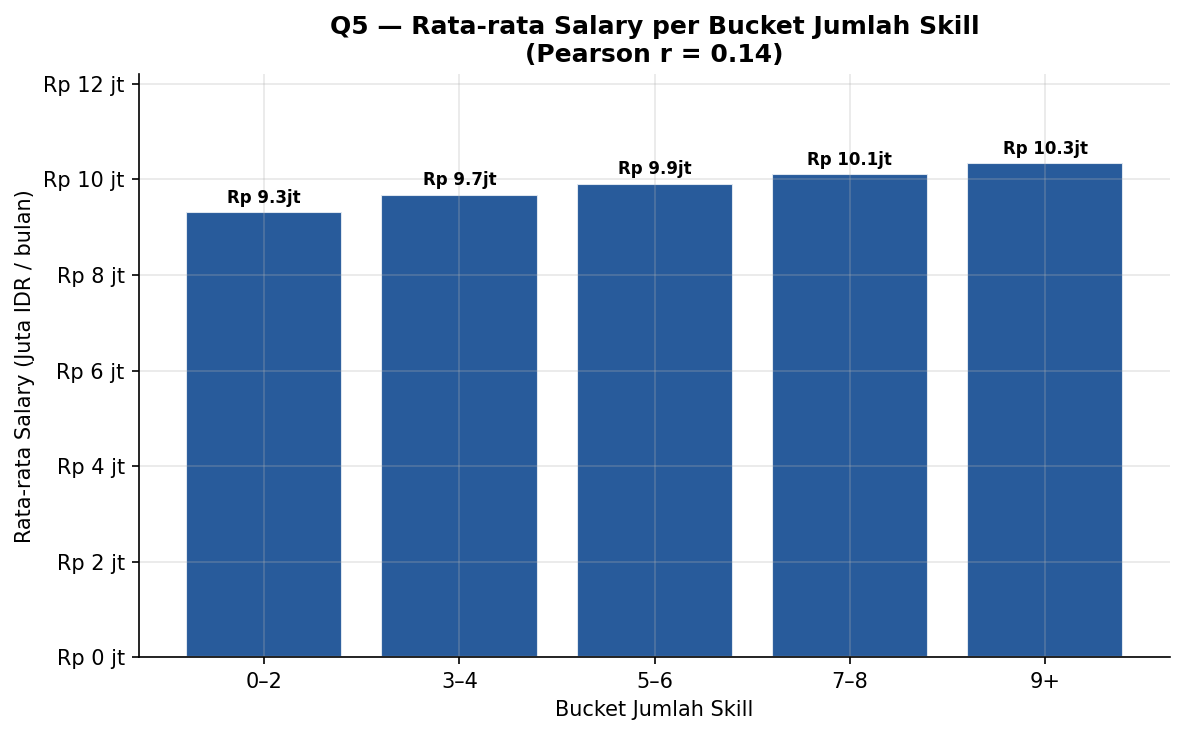

Pearson Correlation (skills_count vs salary_avg): 0.143


In [56]:
df_corr = df_merge[df_merge['salary_avg'].notna()].copy()
df_corr['salary_avg_jt'] = df_corr['salary_avg'] / 1_000_000

# Hapus outlier ekstrem (> 99th percentile)
p99      = df_corr['salary_avg_jt'].quantile(0.99)
df_corr  = df_corr[df_corr['salary_avg_jt'] <= p99]
corr_val = df_corr[['skills_count', 'salary_avg_jt']].corr().iloc[0, 1]

# Bar chart: avg salary per skills_count bucket
df_corr['skills_bucket'] = pd.cut(
    df_corr['skills_count'],
    bins=[0, 2, 4, 6, 8, 100],
    labels=['0–2', '3–4', '5–6', '7–8', '9+']
)
bucket_avg = df_corr.groupby('skills_bucket', observed=True)['salary_avg_jt'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(bucket_avg.index, bucket_avg.values,
       color='#023E8A', alpha=0.85, edgecolor='white')

for i, (idx, val) in enumerate(bucket_avg.items()):
    ax.text(i, val + 0.2, f'Rp {val:.1f}jt', ha='center', fontsize=8, fontweight='bold')

ax.set_xlabel('Bucket Jumlah Skill')
ax.set_ylabel('Rata-rata Salary (Juta IDR / bulan)')
ax.set_title(f'Q5 — Rata-rata Salary per Bucket Jumlah Skill\n(Pearson r = {corr_val:.2f})',
             fontweight='bold')
ax.set_ylim(0, bucket_avg.max() * 1.18)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('Rp %.0f jt'))
fig.tight_layout()
plt.show()

print(f'Pearson Correlation (skills_count vs salary_avg): {corr_val:.3f}')

**Insight Q5:**
- Nilai Pearson r menunjukkan korelasi **positif lemah hingga sedang** antara jumlah skill dan salary
- Lowongan dengan 7–8 skill cenderung menawarkan salary rata-rata tertinggi
- Namun korelasi tidak kuat, artinya **jumlah skill bukan satu-satunya penentu salary** — faktor lain seperti role, level, dan perusahaan turut berperan signifikan

---
### Q6 — Perusahaan Paling Aktif Merekrut & Salary per Ukuran Perusahaan

**Pertanyaan:** Perusahaan mana yang paling aktif merekrut, dan apakah ukuran perusahaan berpengaruh terhadap salary?

Dua visualisasi digunakan:
- **Q6a** : Top 15 perusahaan berdasarkan jumlah lowongan yang diposting
- **Q6b** : Rata-rata salary berdasarkan `company_size_proxy` (fitur hasil feature engineering)

> `company_size_proxy` dikategorikan berdasarkan frekuensi kemunculan perusahaan dalam dataset sebagai proxy ukuran perusahaan.

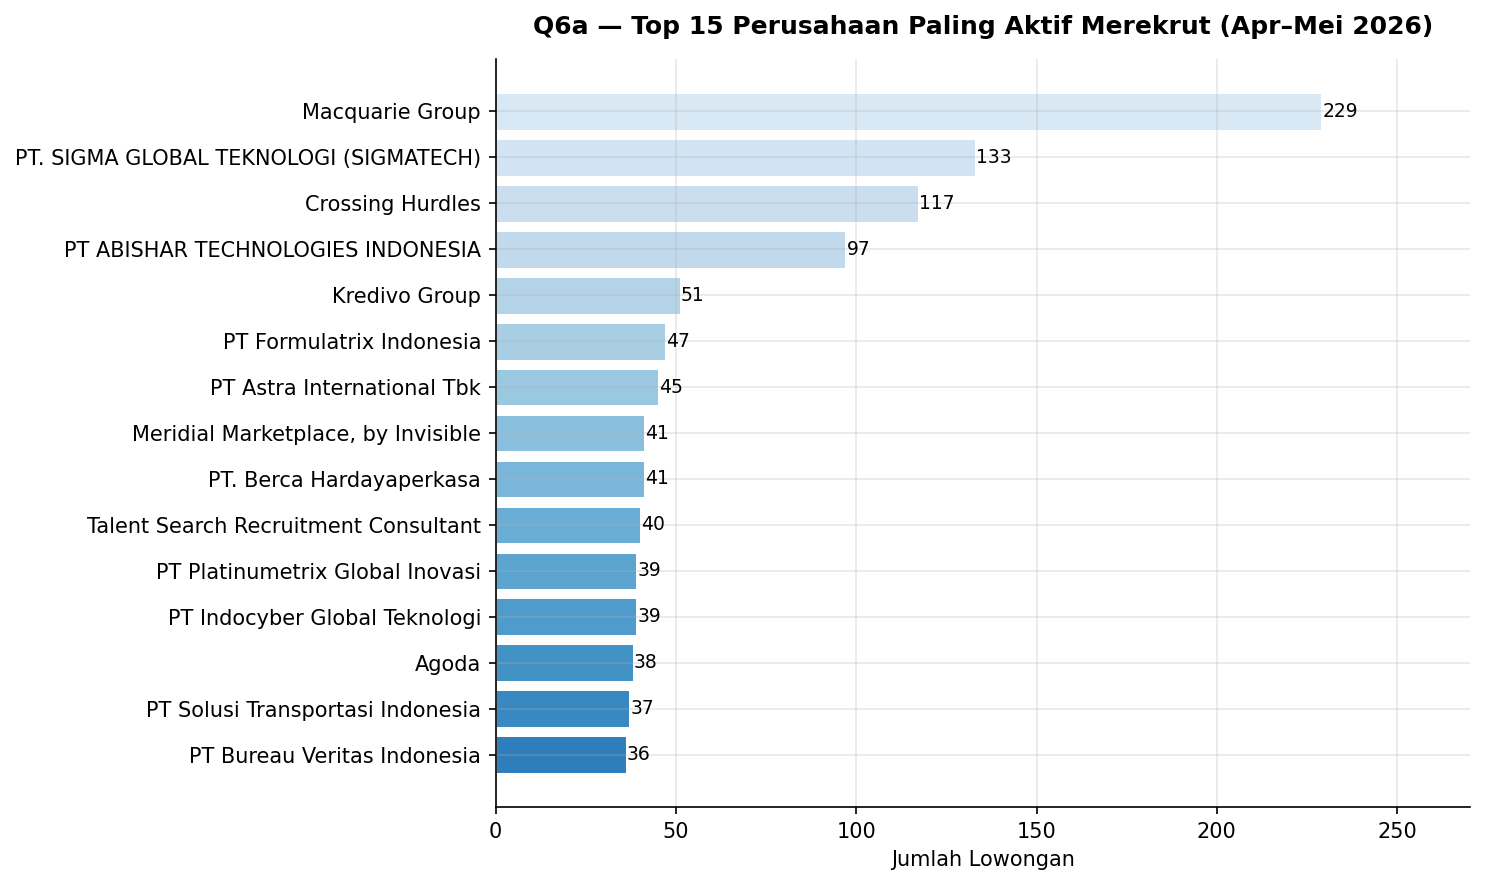

In [57]:
# ── Q6a: Top 15 perusahaan paling aktif merekrut ─────────────
freq  = df_merge['company'].value_counts()
df_merge['company_hiring_freq'] = df_merge['company'].map(freq)
df_merge['company_size_proxy']  = pd.cut(
    df_merge['company_hiring_freq'],
    bins=[0, 2, 5, 10, 9999],
    labels=['Small (1–2)', 'Medium (3–5)', 'Large (6–10)', 'Enterprise (10+)']
)

top15 = freq.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = plt.cm.Blues_r(np.linspace(0.3, 0.85, len(top15)))
bars = ax.barh(top15.index[::-1], top15.values[::-1],
               color=colors_bar, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, top15.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('Jumlah Lowongan')
ax.set_title('Q6a — Top 15 Perusahaan Paling Aktif Merekrut (Apr–Mei 2026)',
             fontweight='bold', pad=12)
ax.set_xlim(0, top15.max() * 1.18)
fig.tight_layout()
plt.show()

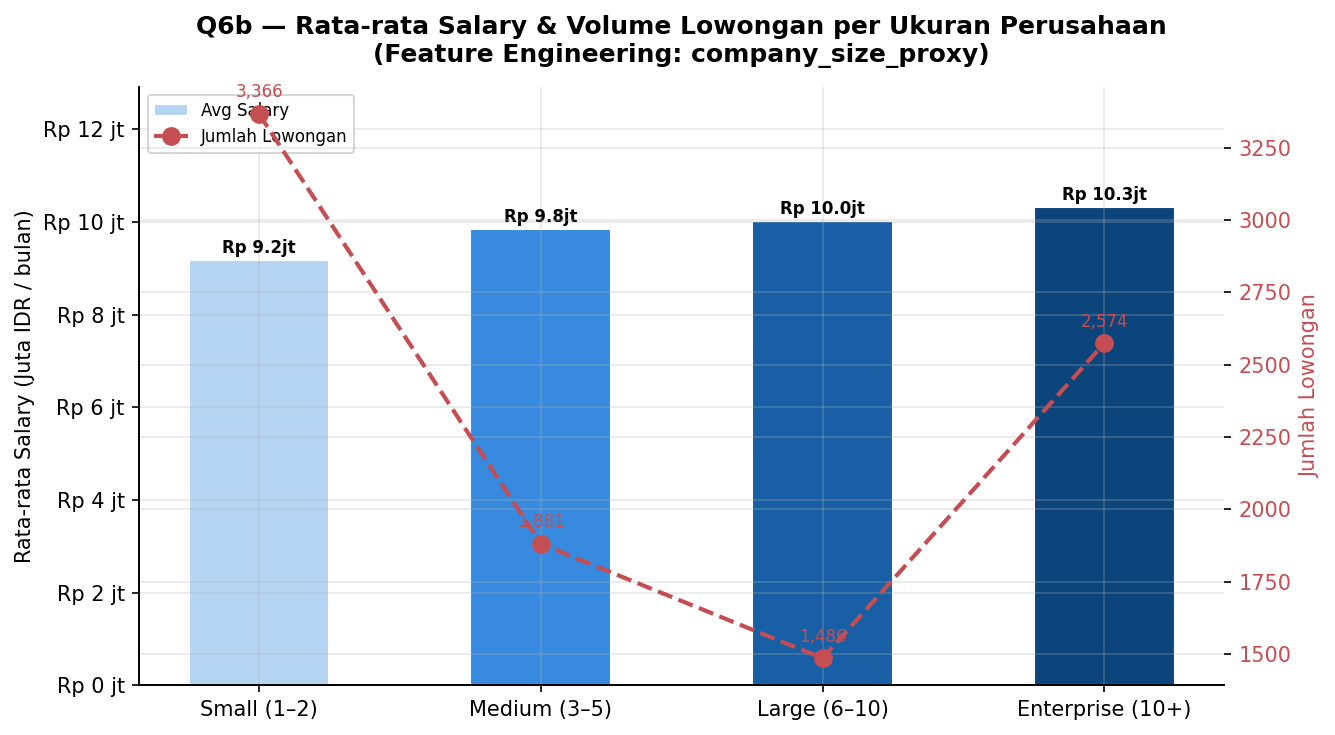

In [58]:
# ── Q6b: Avg salary per company_size_proxy ───────────────────
df_sal_proxy = df_merge[df_merge['salary_avg'].notna()].copy()
df_sal_proxy['salary_avg_jt'] = df_sal_proxy['salary_avg'] / 1_000_000

size_order = ['Small (1–2)', 'Medium (3–5)', 'Large (6–10)', 'Enterprise (10+)']
size_avg   = (df_sal_proxy.groupby('company_size_proxy', observed=True)['salary_avg_jt']
              .mean().reindex(size_order))
size_count = df_sal_proxy['company_size_proxy'].value_counts().reindex(size_order)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

size_colors = ['#B5D4F4', '#378ADD', '#185FA5', '#0C447C']
bars = ax1.bar(size_order, size_avg.values, color=size_colors,
               edgecolor='white', width=0.5, label='Avg Salary')
ax2.plot(size_order, size_count.values, 'o--',
         color='#C44E52', linewidth=2, markersize=8, label='Jumlah Lowongan')

for bar, val in zip(bars, size_avg.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
             f'Rp {val:.1f}jt', ha='center', fontsize=8, fontweight='bold')

for i, (s, c) in enumerate(zip(size_order, size_count.values)):
    ax2.annotate(f'{c:,}', (i, c), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=8, color='#C44E52')

ax1.set_ylabel('Rata-rata Salary (Juta IDR / bulan)')
ax2.set_ylabel('Jumlah Lowongan', color='#C44E52')
ax2.tick_params(axis='y', labelcolor='#C44E52')
ax1.set_title('Q6b — Rata-rata Salary & Volume Lowongan per Ukuran Perusahaan\n(Feature Engineering: company_size_proxy)',
              fontweight='bold', pad=12)
ax1.set_ylim(0, size_avg.max() * 1.25)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('Rp %.0f jt'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')
fig.tight_layout()
plt.show()

**Insight Q6:**
- Perusahaan teknologi besar dan konsultan IT mendominasi daftar perusahaan paling aktif merekrut
- Perusahaan **Enterprise (10+ lowongan)** cenderung menawarkan salary rata-rata lebih tinggi dibanding perusahaan kecil
- Namun perusahaan kecil (Small) memiliki jumlah lowongan lebih banyak — menunjukkan ekosistem startup yang aktif
- Terdapat trade-off antara ukuran perusahaan dan volume rekrutmen

---
### Q7 — Variasi Job Title & Pengaruh Seniority Terhadap Salary

**Pertanyaan:** Seberapa beragam variasi job title per role, dan apakah seniority dalam judul pekerjaan berkorelasi dengan salary?

Fitur `title_seniority` diekstrak dari judul pekerjaan menggunakan keyword matching (Senior, Junior, Lead, dll). Analisis ini melihat:
- **Q7a** : Rata-rata salary berdasarkan `title_seniority`
- **Q7b** : Jumlah unique job title per role (keberagaman variasi title)

/tmp/ipykernel_2146/3173961598.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sen_avg.index, rotation=20, ha='right', fontsize=9)


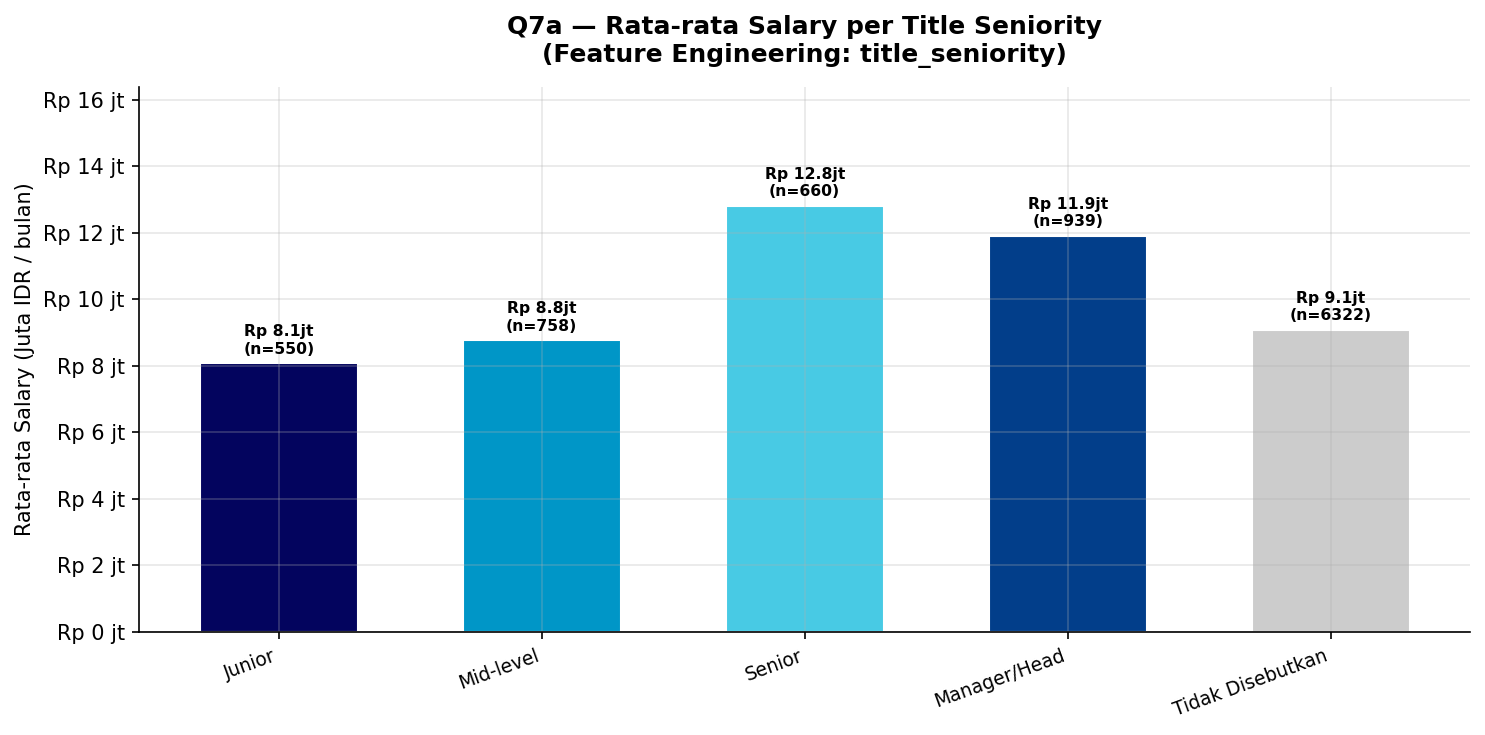

In [59]:
SENIORITY_ORDER  = ['Junior', 'Mid-level', 'Senior', 'Manager/Head', 'Tidak Disebutkan']
SENIORITY_COLORS = {
    'Junior'           : '#03045E',
    'Mid-level'        : '#0096C7',
    'Senior'           : '#48CAE4',
    'Manager/Head'     : '#023E8A',
    'Tidak Disebutkan' : '#CCCCCC',
}

# ── Q7a: Avg salary per title_seniority ──────────────────────
df_sal_sen = df_merge[df_merge['salary_avg'].notna()].copy()
df_sal_sen['salary_avg_jt'] = df_sal_sen['salary_avg'] / 1_000_000
p99        = df_sal_sen['salary_avg_jt'].quantile(0.99)
df_sal_sen = df_sal_sen[df_sal_sen['salary_avg_jt'] <= p99]

sen_avg   = (df_sal_sen.groupby('title_seniority')['salary_avg_jt']
             .mean().reindex(SENIORITY_ORDER).dropna())
sen_count = (df_sal_sen['title_seniority'].value_counts()
             .reindex(SENIORITY_ORDER).fillna(0).astype(int))

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [SENIORITY_COLORS.get(s, '#999') for s in sen_avg.index]
bars = ax.bar(sen_avg.index, sen_avg.values,
              color=bar_colors, edgecolor='white', width=0.6)

for bar, val, cnt in zip(bars, sen_avg.values,
                         sen_count.reindex(sen_avg.index).values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'Rp {val:.1f}jt\n(n={cnt})',
            ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_ylabel('Rata-rata Salary (Juta IDR / bulan)')
ax.set_title('Q7a — Rata-rata Salary per Title Seniority\n(Feature Engineering: title_seniority)',
             fontweight='bold', pad=12)
ax.set_xticklabels(sen_avg.index, rotation=20, ha='right', fontsize=9)
ax.set_ylim(0, sen_avg.max() * 1.28)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('Rp %.0f jt'))
fig.tight_layout()
plt.show()

/tmp/ipykernel_2146/1357904162.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(unique_titles.index, rotation=25, ha='right', fontsize=9)


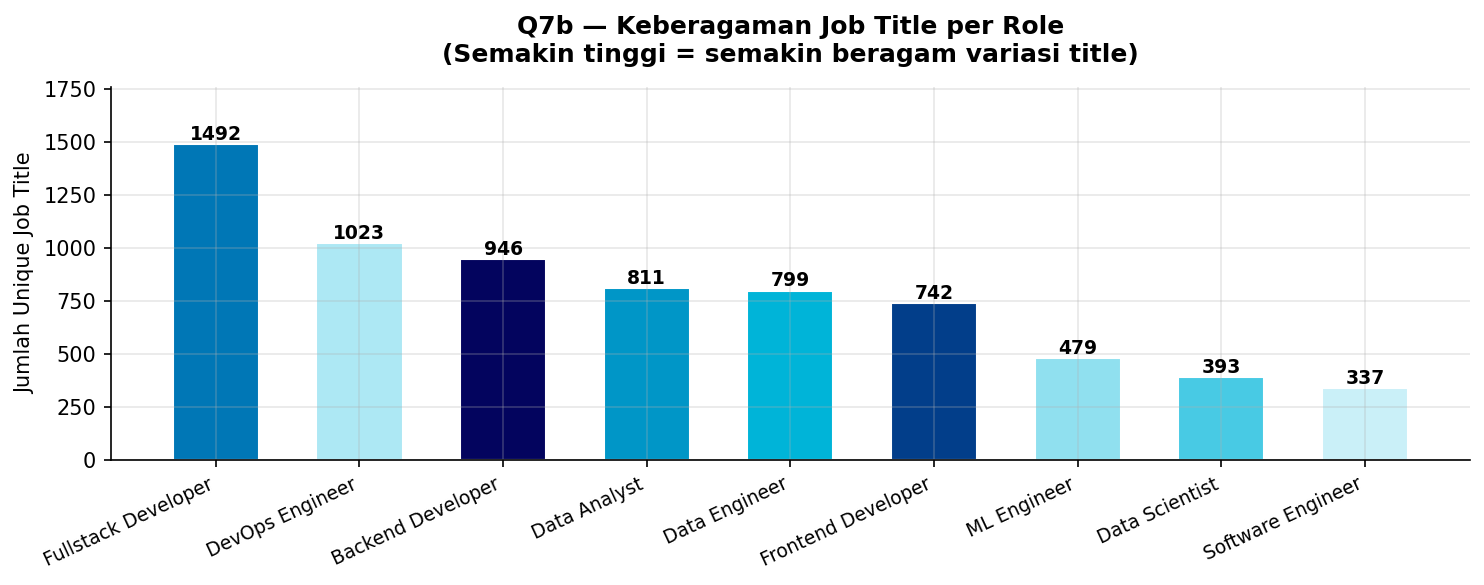

In [60]:
# ── Q7b: Jumlah unique title per role ────────────────────────
unique_titles = (df_merge.groupby('search_role')['title']
                 .nunique().reindex(ROLE_ORDER).sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(unique_titles.index, unique_titles.values,
              color=[ROLE_COLORS.get(r, '#999') for r in unique_titles.index],
              edgecolor='white', width=0.6)

for bar, val in zip(bars, unique_titles.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Jumlah Unique Job Title')
ax.set_title('Q7b — Keberagaman Job Title per Role\n(Semakin tinggi = semakin beragam variasi title)',
             fontweight='bold', pad=12)
ax.set_xticklabels(unique_titles.index, rotation=25, ha='right', fontsize=9)
ax.set_ylim(0, unique_titles.max() * 1.18)
fig.tight_layout()
plt.show()

**Insight Q7:**
- **Manager/Head** dan **Senior** level secara konsisten menawarkan salary tertinggi, mengkonfirmasi bahwa seniority dalam judul pekerjaan berkorelasi positif dengan kompensasi
- **Junior** memiliki salary terendah namun jumlah lowongan yang cukup banyak — cocok untuk fresh graduate
- **Software Engineer** dan **Data Analyst** memiliki variasi job title terbanyak, menunjukkan bahwa kedua role ini memiliki cakupan pekerjaan yang paling luas
- Role dengan variasi title sedikit (seperti DevOps) cenderung lebih terdefinisi dan spesifik dalam kebutuhan kompetensinya

---
## 5. Kesimpulan

Berdasarkan analisis terhadap data lowongan kerja IT di Indonesia periode April–Mei 2026:

### Q1 — Role Paling Dibutuhkan
**Backend Developer** dan **Software Engineer** mendominasi pasar kerja IT Indonesia, mencerminkan tingginya kebutuhan pengembang aplikasi server-side.

### Q2 — Skill Paling Dicari
**SQL**, **Python**, dan **JavaScript** adalah skill paling universal. Setiap role memiliki skill spesifik — data roles membutuhkan Python & SQL, developer roles membutuhkan JavaScript & framework terkait.

### Q3 — Salary per Role
Role data (**Data Scientist**, **ML Engineer**, **Data Engineer**) menawarkan salary rata-rata tertinggi, mencerminkan tingginya permintaan dan terbatasnya supply talenta di bidang ini.

### Q4 — Distribusi Job Level
Mayoritas lowongan tidak mencantumkan level secara eksplisit. Role data cenderung membutuhkan level lebih senior, sementara developer roles lebih terbuka untuk entry-level.

### Q5 — Korelasi Skill vs Salary
Terdapat korelasi positif lemah antara jumlah skill dan salary. Kualitas dan relevansi skill lebih penting daripada kuantitasnya semata.

### Q6 — Perusahaan & Ukuran Perusahaan
Perusahaan **Enterprise** menawarkan salary rata-rata lebih tinggi. Namun jumlah lowongan terbanyak justru berasal dari perusahaan kecil, mencerminkan ekosistem startup yang aktif di Indonesia.

### Q7 — Title Seniority & Keberagaman Title
Seniority dalam judul pekerjaan berkorelasi positif dengan salary — **Manager/Head** dan **Senior** menawarkan kompensasi tertinggi. **Software Engineer** dan **Data Analyst** memiliki variasi job title terbanyak, menunjukkan cakupan pekerjaan yang paling luas.